In [1]:
# ตรวจสอบการใช้งาน GPU บน Colab
!nvidia-smi

# ติดตั้ง Ultralytics (YOLOv8) และไลบรารีที่จำเป็น
!pip install -q ultralytics roboflow opencv-python matplotlib

Tue Sep 22 09:44:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
path = '/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26'

In [5]:
from ultralytics import YOLO

# 1. โหลด Pre-trained Model ขนาดเล็ก (YOLOv11 Nano) เป็น Baseline
model = YOLO("yolo26n.pt")

# 2. ฝึกโมเดลรอบแรกด้วยค่า Default
train_results = model.train(
    data= "/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/data.yaml",  # path to dataset YAML
    epochs=100,  # number of training epochs
    imgsz=640,  # training image size
    device=0,  # use GPU; '0' specifies the first GPU   or device=0,1,2,3 or device=cpu
    workers=2, # use multiple workers for data loading
    seed=42,
    batch=16,
    project='Water Bottle',
    name='tuned_yolov26n',
)




Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=

In [7]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# 1. โหลดน้ำหนักที่ดีที่สุด (best.pt) จากการเทรน Baseline
best_baseline_path = '/content/runs/detect/Water Bottle/tuned_yolov26n/weights/best.pt'
model_eval = YOLO(best_baseline_path)
print(model_eval)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [8]:

# 2. ประเมินผลบน Validation Set
#metrics = model_eval.val(data='/content/drive/MyDrive/Colab Notebooks/yolov11/dataset/data.yaml',conf = 0.4)
metrics = model_eval.val(data='/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/data.yaml',conf = 0.6)

Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 38.5±17.5 MB/s, size: 37.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/valid/labels.cache... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 27.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 2.9s
                   all         92        228      0.972      0.869      0.867      0.687
            bad_bottle         39         42          1      0.905      0.905      0.793
           good_bottle         53         68      0.946      0.824      0.815      0.725
              have_cap         53   

In [9]:
#แสดงระยะเวลาในการประมวลผล ก่อน ประมวลผล และหลัง
print(metrics.speed)

{'preprocess': 6.719790369555519, 'inference': 8.101587630424389, 'loss': 0.0009194021636769479, 'postprocess': 2.38599317391242}


In [10]:
for p in model_eval.parameters():
    print(p)

Streaming output truncated to the last 5000 lines.

         [[-0.0917]],

         [[-0.3062]],

         [[-0.0692]],

         [[-0.0972]],

         [[-0.4102]],

         [[ 0.1804]],

         [[-0.0621]],

         [[-0.2386]],

         [[ 0.1757]],

         [[-0.3594]],

         [[-0.2859]],

         [[-0.2969]],

         [[ 0.1996]],

         [[-0.3645]],

         [[ 0.0328]],

         [[-0.4209]],

         [[-0.0724]],

         [[-0.3218]],

         [[-0.3528]],

         [[-0.2274]],

         [[ 0.1395]],

         [[-0.2101]],

         [[-0.1199]],

         [[-0.3711]],

         [[-0.1534]],

         [[-0.4456]],

         [[-0.3123]],

         [[-0.3809]]]])
Parameter containing:
tensor([-5.8789, -5.8633, -5.9805, -5.9688])
Parameter containing:
tensor([[[[-3.8109e-03, -1.7197e-02,  3.0273e-02],
          [ 1.1492e-03, -3.1414e-03,  4.8492e-02],
          [ 1.4168e-02,  3.1616e-02,  4.0894e-02]],

         [[-2.8900e-02,  2.1326e-01, -1.9928e-02],
        

In [11]:
# 3. แสดงค่าตัววัดประสิทธิภาพสำคัญ

import torch

# Calculate FPS from the metrics object
# metrics.speed is a dictionary containing 'preprocess', 'inference', 'postprocess' times in ms
total_inference_time_ms = metrics.speed['preprocess'] + metrics.speed['inference'] + metrics.speed['postprocess']
fps = 1000 / total_inference_time_ms

# Get model size (total number of parameters)
# The model_eval object contains the loaded YOLO model
# We sum the number of elements in each parameter tensor
model_parameters = sum(p.numel() for p in model_eval.parameters())


print("\n================ Baseline Model Performance ================")
print(f"mAP@0.5                 : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95           : {metrics.box.map:.4f}")
print(f"Precision               : {metrics.box.mp:.4f}")
print(f"Recall                  : {metrics.box.mr:.4f}")
print(f"Average FPS             : {fps:.2f}")
print(f"Model Size (Parameters) : {model_parameters:,}")
print("===========================================================\n")



================ Baseline Model Performance ================
mAP@0.5                 : 0.8674
mAP@0.50:0.95           : 0.6867
Precision               : 0.9721
Recall                  : 0.8687
Average FPS             : 58.11
Model Size (Parameters) : 2,505,360



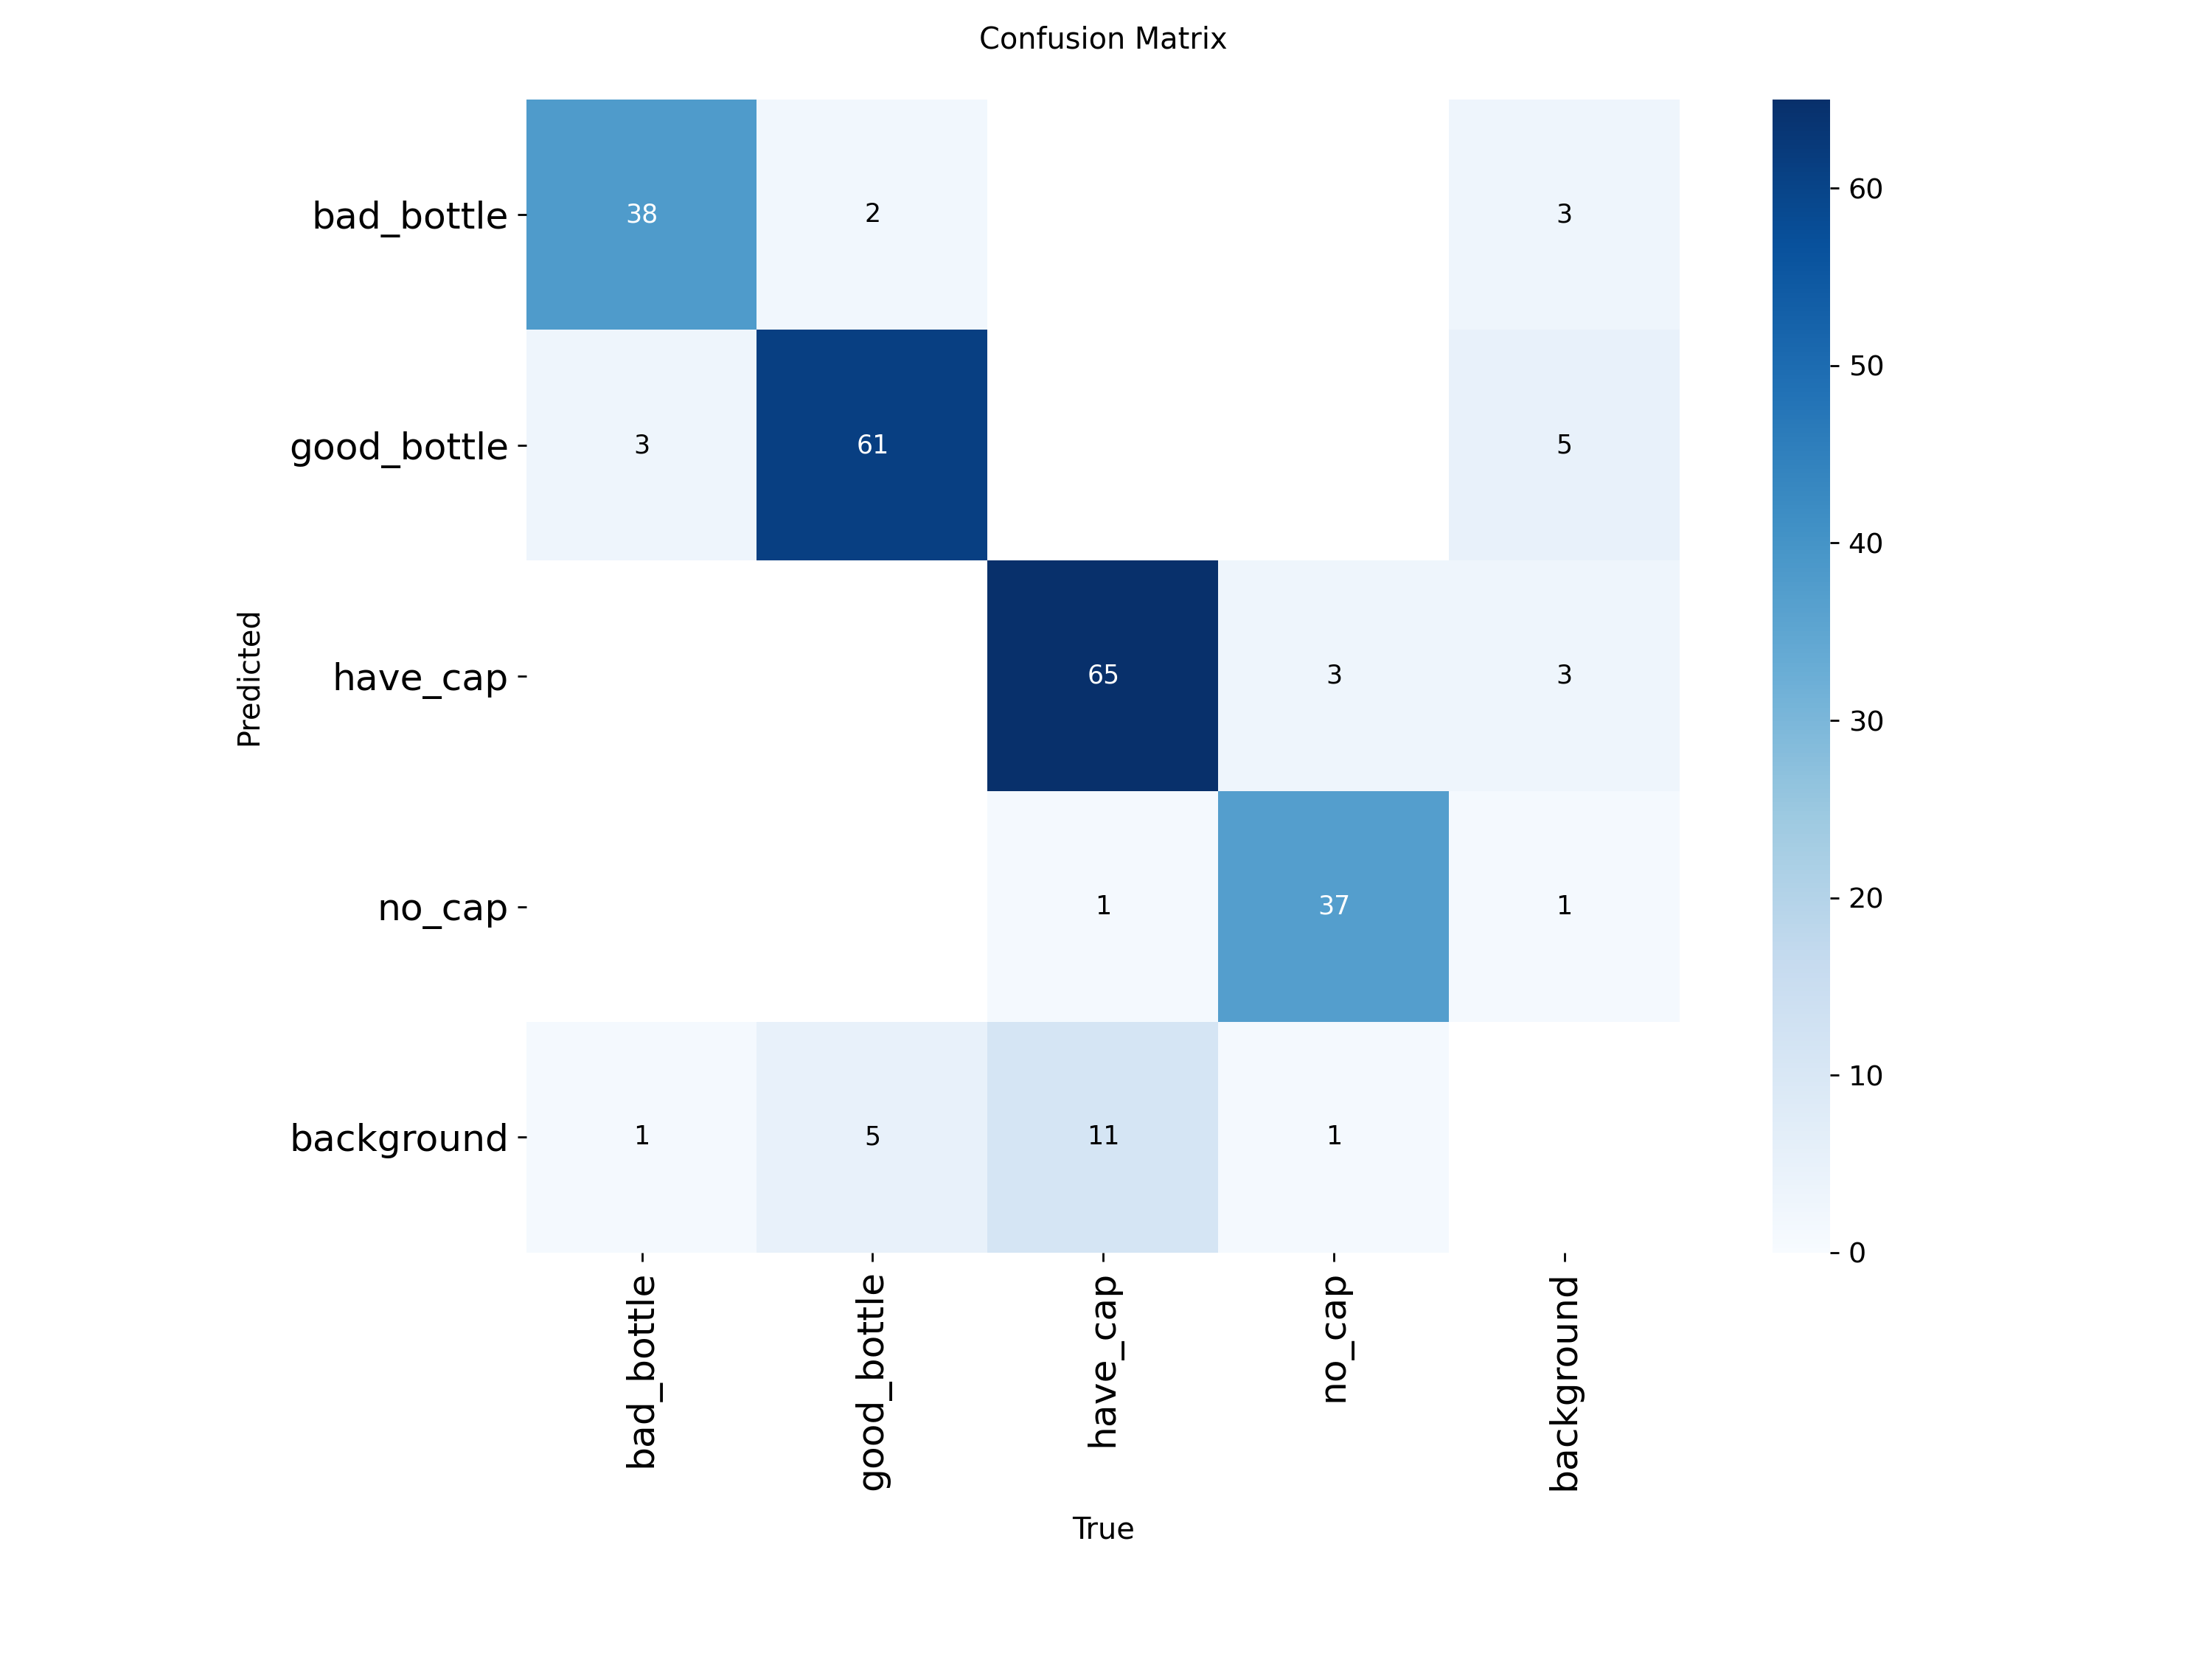

In [12]:
from IPython.display import Image as IPyImage
#แสดงภาพ confusion matrix
IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov26n/confusion_matrix.png', width=600)


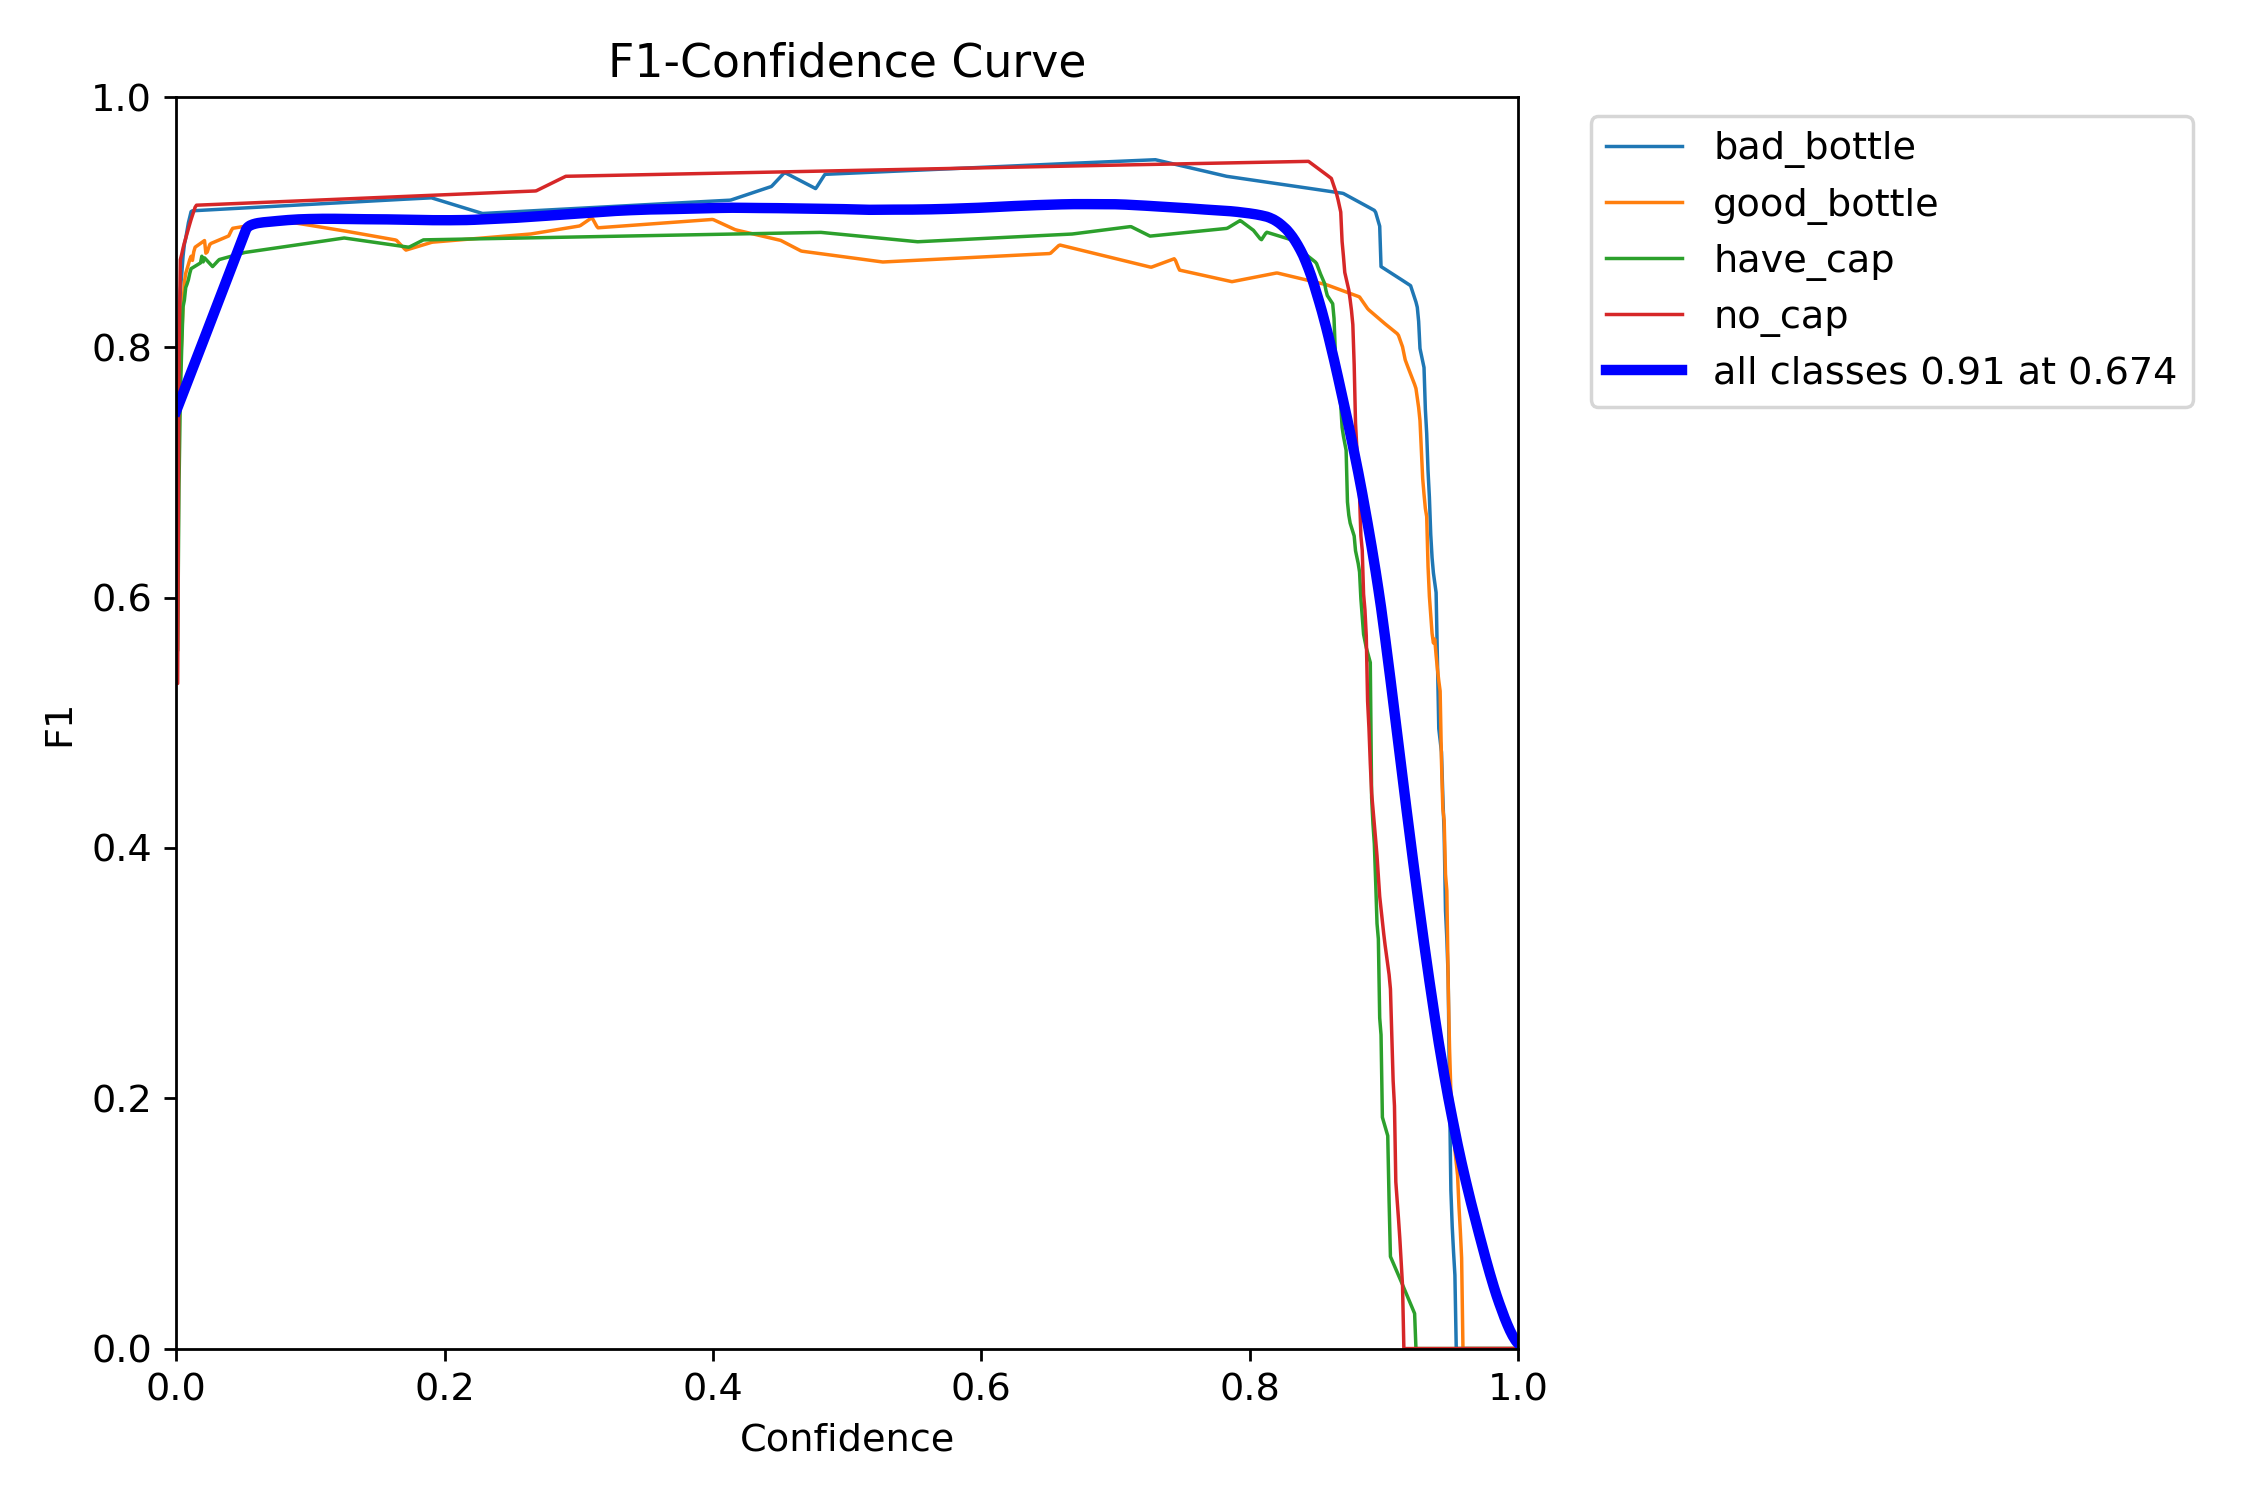

In [13]:
#แสดงภาพ F1-Score Curve
IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov26n/BoxF1_curve.png', width=600)

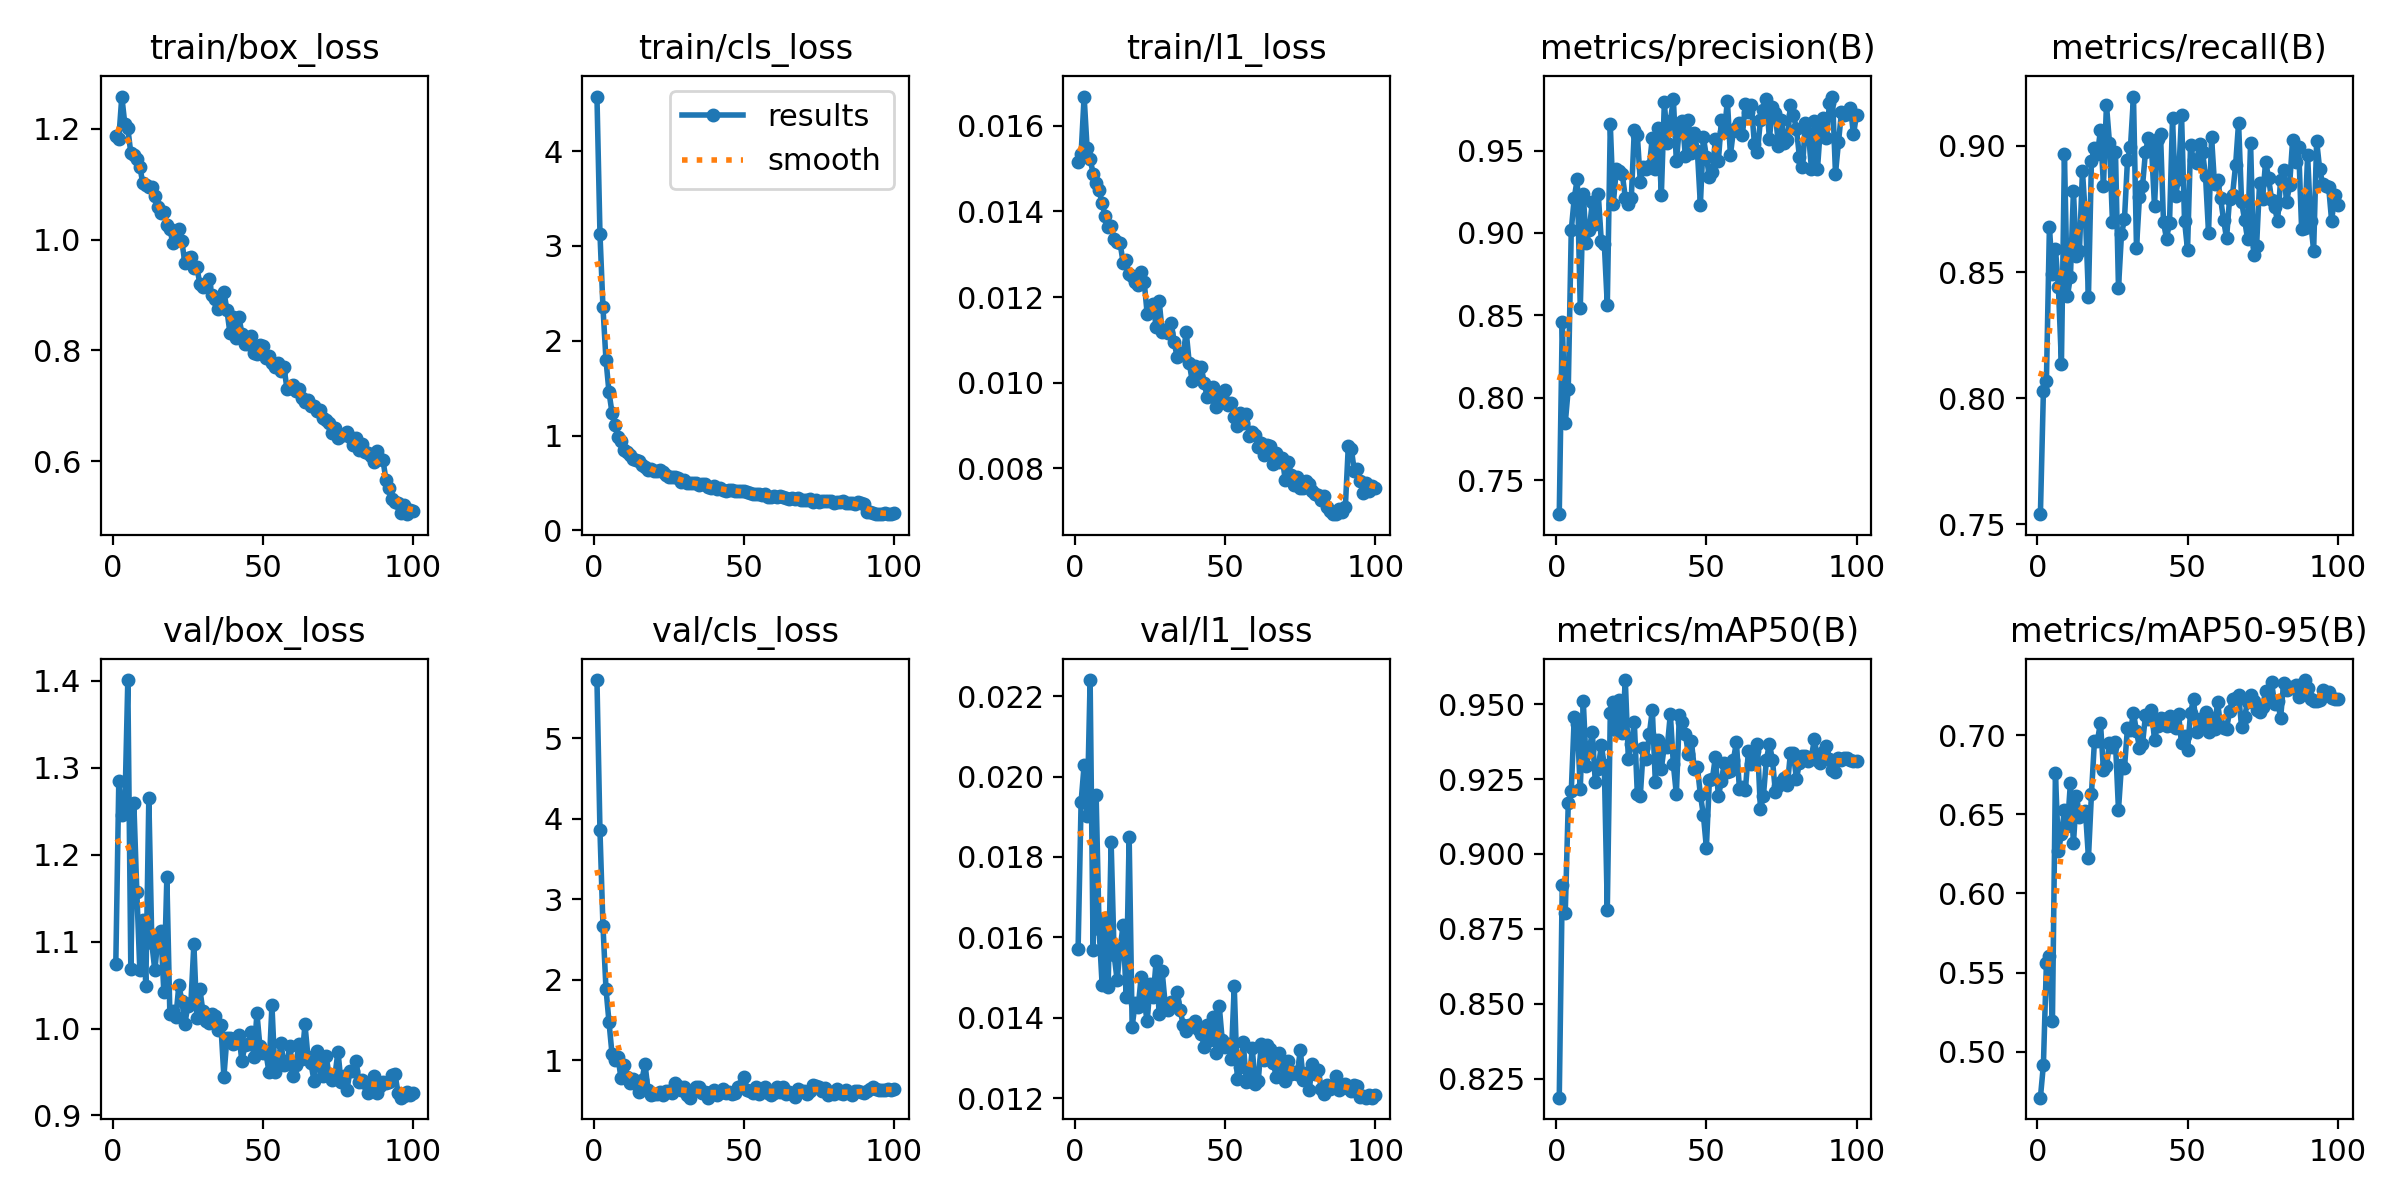

In [14]:
#แสดงกราฟประสิทธิภาพทั้งหมด

IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov26n/results.png', width=600)

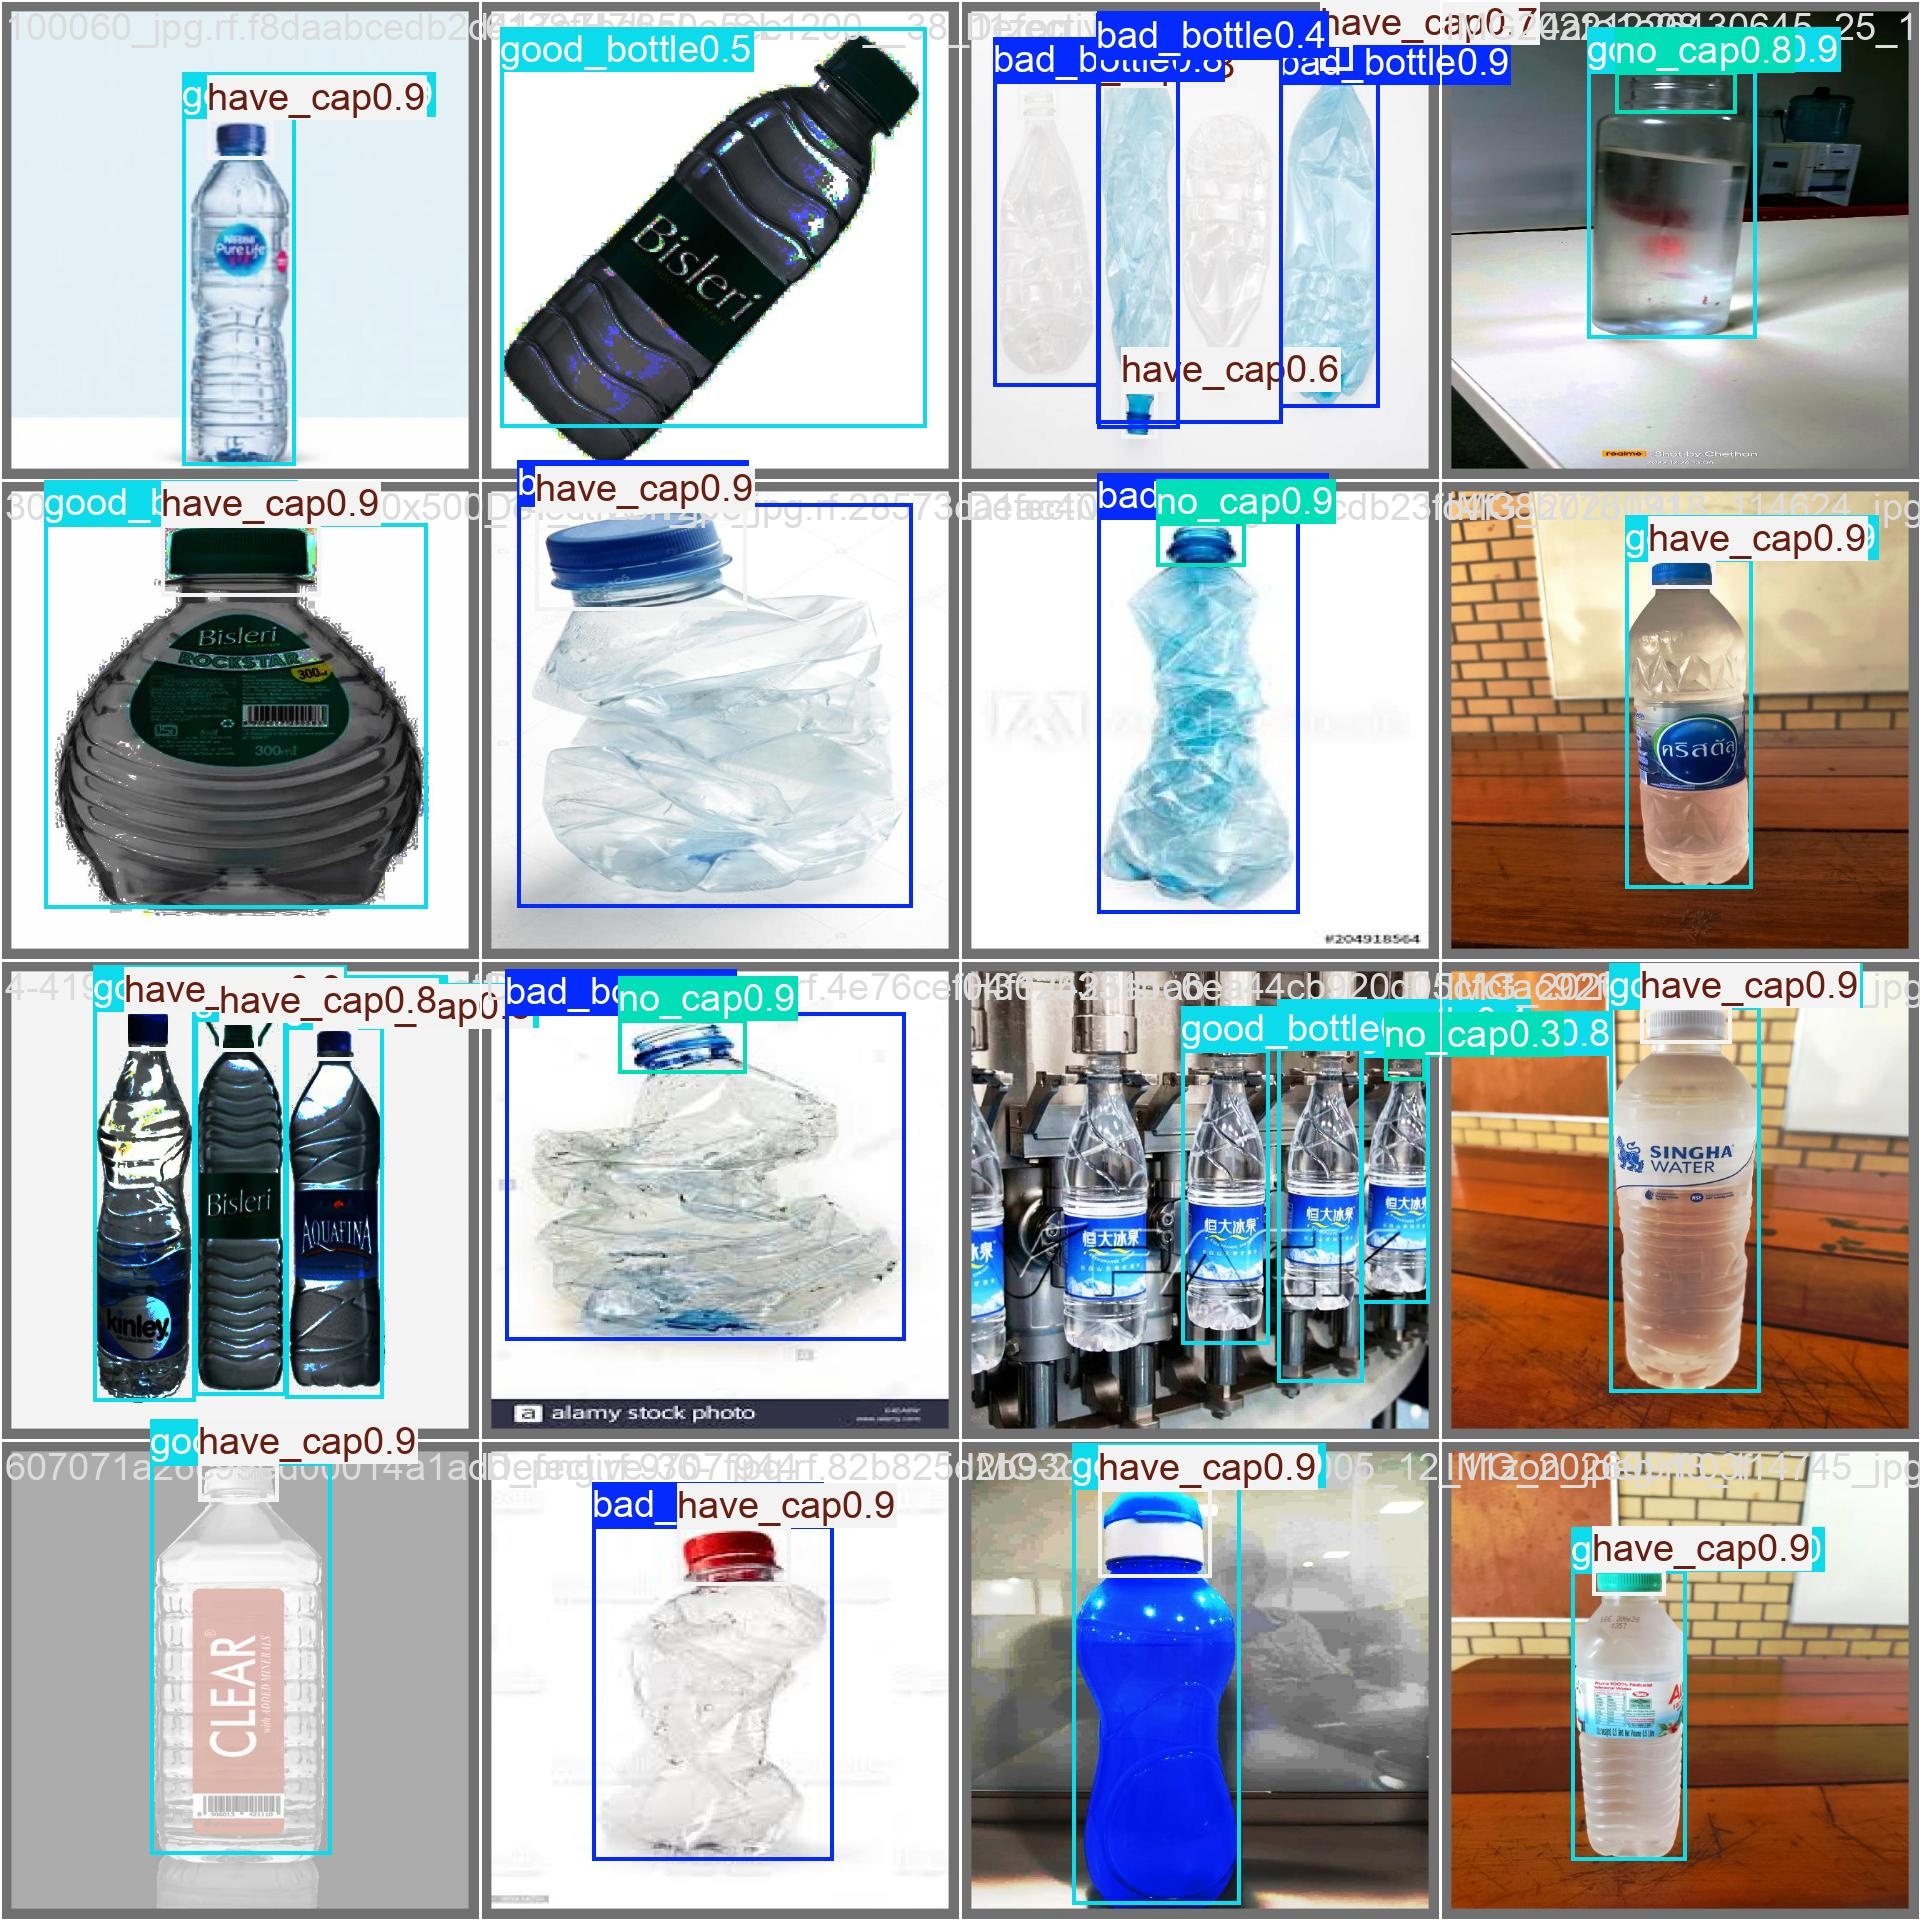

In [15]:
#แสดงผลลัพธ์กับชุด Validate

IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov26n/val_batch0_pred.jpg', width=600)

In [16]:
# กลยุทธ์ในการปรับแต่ง (Optimization Strategies):
# 1. เปลี่ยนใช้ yolov11s.pt (Small Model) เพื่อเพิ่ม Capacity ในการเรียนรู้ลักษณะขนและใบหน้าสุนัข
# 2. เปลี่ยน Optimizer เป็น AdamW ช่วยเพิ่มความเสถียรในการปรับ Weight
# 3. เพิ่ม Data Augmentation (Mosaic, Mixup, Random Rotation) ป้องกัน Overfitting

model_tuned = YOLO('yolo26s.pt')

results_tuned = model_tuned.train(
    data='/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/data.yaml',
    epochs=70,
    imgsz=640,
    batch=16,
    optimizer='AdamW',       # เปลี่ยนเป็น AdamW Optimizer
    lr0=0.001,               # Initial Learning Rate
    lrf=0.01,                # Final Learning Rate Ratio
    momentum=0.937,
    weight_decay=0.0005,
    mosaic=1.0,              # ผสาน 4 ภาพ เพิ่มความสามารถจับสุนัขมุมแปลกๆ
    mixup=0.2,               # ซ้อนทับภาพ ช่วยกรณีสุนัขยืนบังกัน
    degrees=10.0,            # สุ่มหมุนภาพ +-15 องศา
    fliplr=0.5,              # สุ่มพลิกภาพซ้าย-ขวา
    patience=15,             # Early stopping หาก Loss ไม่ลดใน 15 Epochs
    project='dog_breed_project',
    name='tuned_yolov26s',
    seed=42
)

New https://pypi.org/project/ultralytics/8.4.159 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=30

In [17]:
# 1. ประเมินผลโมเดล Fine-Tuned จาก best.pt ตัวใหม่
best_tuned_path = '/content/runs/detect/dog_breed_project/tuned_yolov26s/weights/best.pt'
model_tuned_eval = YOLO(best_tuned_path)
metrics_tuned = model_tuned_eval.val(data='/content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/data.yaml')

# 2. คำนวณค่า  FPS และหา model parameters สำหรับ tuned model
total_inference_time_ms_tuned = metrics_tuned.speed['preprocess'] + metrics_tuned.speed['inference'] + metrics_tuned.speed['postprocess']
fps_tuned = 1000 / total_inference_time_ms_tuned
model_parameters_tuned = sum(p.numel() for p in model_tuned_eval.parameters())

# 3. คำนวณผลต่าง
map50_diff = metrics_tuned.box.map50 - metrics.box.map50
map5095_diff = metrics_tuned.box.map - metrics.box.map
p_diff = metrics_tuned.box.mp - metrics.box.mp
r_diff = metrics_tuned.box.mr - metrics.box.mr
fps_diff = fps_tuned - fps
model_parameters_diff = model_parameters_tuned - model_parameters


Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,466,728 parameters, 0 gradients, 20.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 35.5±7.9 MB/s, size: 40.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Colab Notebooks/Project ML/Yolo26/valid/labels.cache... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 19.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.3s
                   all         92        228      0.975      0.946      0.973      0.721
            bad_bottle         39         42          1      0.976      0.992       0.81
           good_bottle         53         68      0.951      0.912      0.975      0.805
              have_cap         53   

In [18]:

# 4.และแสดงตารางเปรียบเทียบ
print("\n" + "="*72)
print(f"{'Metric':<18} | {'Baseline (v11n)':<15} | {'Tuned (v11s)':<15} | {'Improvement':<12}")
print("-" * 72)
print(f"{'mAP@0.5':<18} | {metrics.box.map50:<15.4f} | {metrics_tuned.box.map50:<15.4f} | {map50_diff:+12.4f}")
print(f"{'mAP@0.50:0.95':<18} | {metrics.box.map:<15.4f} | {metrics_tuned.box.map:<15.4f} | {map5095_diff:+12.4f}")
print(f"{'Precision':<18} | {metrics.box.mp:<15.4f} | {metrics_tuned.box.mp:<15.4f} | {p_diff:+12.4f}")
print(f"{'Recall':<18} | {metrics.box.mr:<15.4f} | {metrics_tuned.box.mr:<15.4f} | {r_diff:+12.4f}")
print(f"{'FPS':<18} | {fps:<15.2f} | {fps_tuned:<15.2f} | {fps_diff:+12.2f}")
print(f"{'Model Size(Params)':<18} | {model_parameters:<15,} | {model_parameters_tuned:<15,} | {model_parameters_diff:+12,}")
print("="*72 + "\n")


Metric             | Baseline (v11n) | Tuned (v11s)    | Improvement 
------------------------------------------------------------------------
mAP@0.5            | 0.8674          | 0.9728          |      +0.1055
mAP@0.50:0.95      | 0.6867          | 0.7215          |      +0.0348
Precision          | 0.9721          | 0.9748          |      +0.0027
Recall             | 0.8687          | 0.9457          |      +0.0770
FPS                | 58.11           | 50.74           |        -7.37
Model Size(Params) | 2,505,360       | 9,950,960       |   +7,445,600

